**Newton's cooling law**

Newton's Law of Cooling is governed by the differential equation:
$$ \frac{du}{dt} = - k (u-T).$$
The exact solution of Newton's Law of Cooling is

$$u(t)
=T+(u_0 - T) e^{-k⋅t}
$$

Let's generate 10 data points from the exact solution of Newton's Law of Cooling with the specified parameters

T=30 (ambient temperature)
u_0 =90 (initial temperature)
k=0.5 (cooling constant)

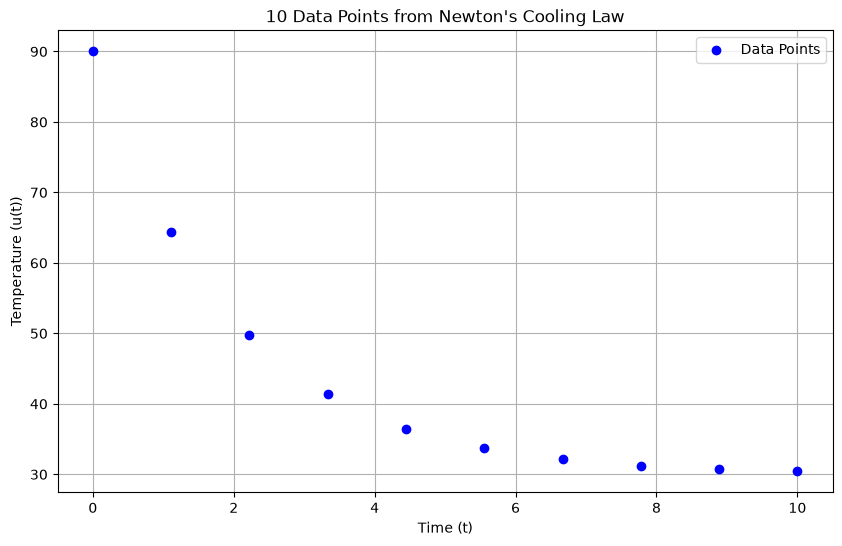

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Constants for Newton's Law of Cooling
T = 30       # Ambient temperature
u0 = 90      # Initial temperature
k = 0.5      # Decay constant

# Exact solution of Newton's Law of Cooling
def exact_solution(t):
    return T + (u0 - T) * np.exp(-k * t)

# Generate 10 data points from the exact solution
t_data = np.linspace(0, 10, 10).reshape(-1, 1)  # 10 points in the interval [0, 10]
u_data = exact_solution(t_data)

# Plot the 10 data points (without the exact solution line)
plt.figure(figsize=(10, 6))
plt.scatter(t_data, u_data, color='b', label="Data Points", zorder=5)
plt.xlabel('Time (t)')
plt.ylabel('Temperature (u(t))')
plt.title("10 Data Points from Newton's Cooling Law")
plt.legend()
plt.grid(True)
plt.show()


We pick just a few data points. The first thing is to use non-linear regression to fit a model through the data points (this is just Statistics!)

To solve Newton's Law of Cooling using polynomial regression with degrees 1, 2, 3, and 4, we'll:

Generate 7 data points from the exact solution of Newton's Law of Cooling.
Fit polynomial regression models with varying degrees (1 to 4).
Plot the exact solution, the data points, and the fitted polynomial regression curves.

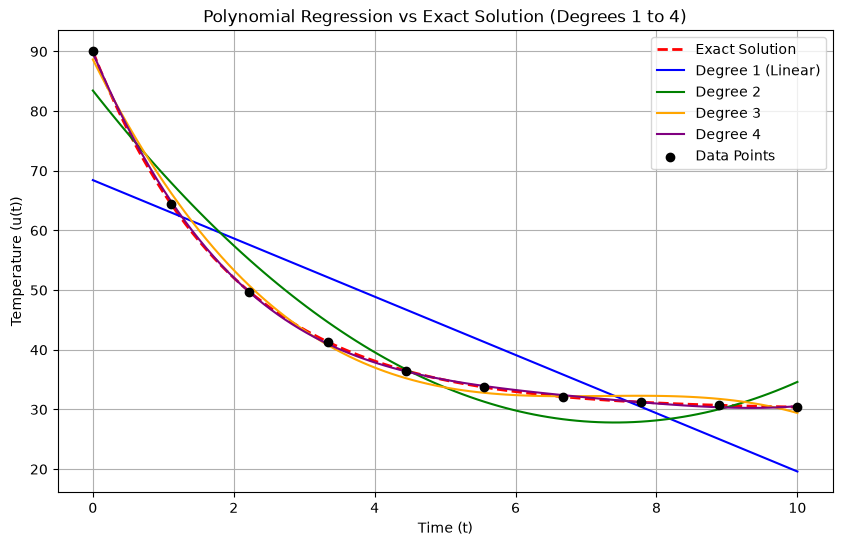

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Constants for Newton's Law of Cooling
T = 30       # Ambient temperature
u0 = 90      # Initial temperature
k = 0.5      # Decay constant

# Exact solution of Newton's Law of Cooling
def exact_solution(t):
    return T + (u0 - T) * np.exp(-k * t)

# Function to perform polynomial regression and predict values
def polynomial_regression(t_data, u_data, degree, t_test):
    poly = PolynomialFeatures(degree)
    t_poly = poly.fit_transform(t_data)

    # Train the model
    model = LinearRegression()
    model.fit(t_poly, u_data)

    # Predict values using the fitted model
    t_test_poly = poly.transform(t_test)
    u_pred = model.predict(t_test_poly)

    return u_pred

# Generate 7 data points from the exact solution
t_data = np.linspace(0, 10, 10).reshape(-1, 1)  # 7 points in the interval [0, 10]
u_data = exact_solution(t_data)

# Generate a range of time values for plotting
t_test = np.linspace(0, 10, 100).reshape(-1, 1)

# Perform polynomial regression for degrees 1, 2, 3, and 4
u_pred_deg1 = polynomial_regression(t_data, u_data, 1, t_test)
u_pred_deg2 = polynomial_regression(t_data, u_data, 2, t_test)
u_pred_deg3 = polynomial_regression(t_data, u_data, 3, t_test)
u_pred_deg4 = polynomial_regression(t_data, u_data, 4, t_test)

# Exact solution for comparison
u_exact = exact_solution(t_test)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(t_test, u_exact, label="Exact Solution", linestyle='dashed', color='r', linewidth=2)
plt.plot(t_test, u_pred_deg1, label="Degree 1 (Linear)", color='b', linestyle='-', linewidth=1.5)
plt.plot(t_test, u_pred_deg2, label="Degree 2", color='g', linestyle='-', linewidth=1.5)
plt.plot(t_test, u_pred_deg3, label="Degree 3", color='orange', linestyle='-', linewidth=1.5)
plt.plot(t_test, u_pred_deg4, label="Degree 4", color='purple', linestyle='-', linewidth=1.5)

# Plot the original data points
plt.scatter(t_data, u_data, color='black', label="Data Points", zorder=5)

# Add labels and title
plt.xlabel('Time (t)')
plt.ylabel('Temperature (u(t))')
plt.title("Polynomial Regression vs Exact Solution (Degrees 1 to 4)")
plt.legend()
plt.grid(True)
plt.show()


**Unsupervised Learning**

We shall use a Physics-Informed Neural Network.
Thus, we set up a neural network that takes time
$t$ as input and outputs
$u(t)$ as the predicted temperature.

The loss function is composed of two parts:

$(i)$ Initial condition loss: Ensures the model satisfies
$u(0)=90$.

$(ii)$ Differential equation loss:
Ensures the model satisfies Newton's Law of cooling

Training: We will train the neural network to minimize the total loss, whcich is the sum of the aforementioned losses.

Plotting: We'll plot the predicted solution from the PINN against the exact solution for comparison reasons.

The first code uses two hiddenlayers with tanh activations and 5000 epochs of training.

Epoch 0, Loss: [[24509.58]]
Epoch 500, Loss: [[15666.821]]
Epoch 1000, Loss: [[11448.043]]
Epoch 1500, Loss: [[8295.285]]
Epoch 2000, Loss: [[5895.7144]]
Epoch 2500, Loss: [[4102.8857]]
Epoch 3000, Loss: [[2811.2117]]
Epoch 3500, Loss: [[1930.1625]]
Epoch 4000, Loss: [[1374.543]]
Epoch 4500, Loss: [[517.1425]]
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7737e9c8f4c0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and h

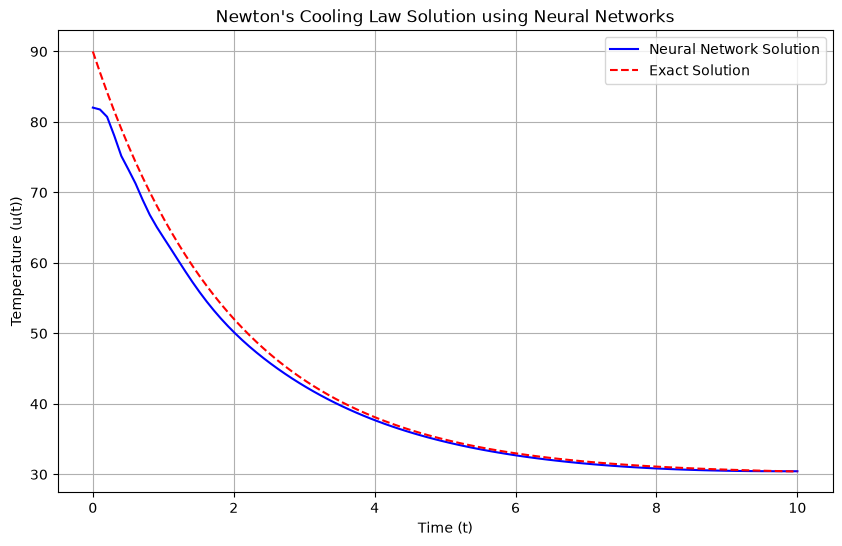

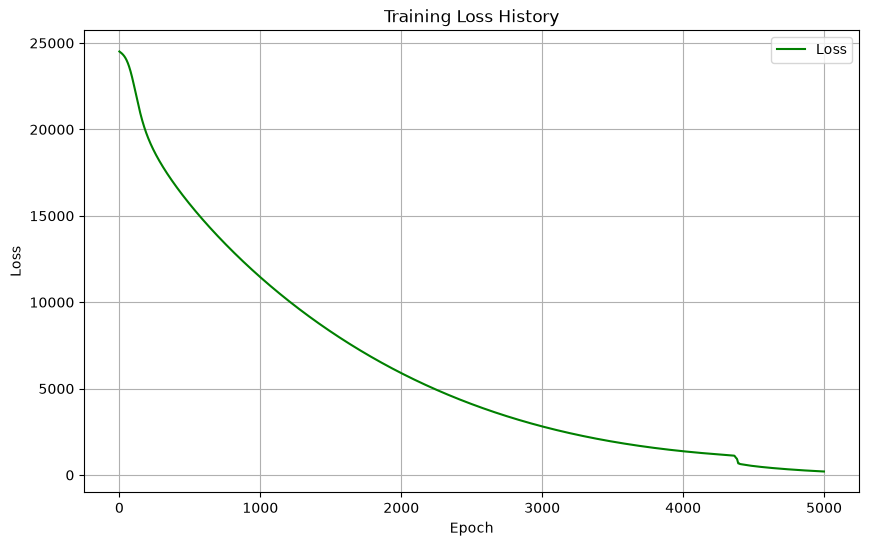

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Constants for the problem
T = 30       # Ambient temperature
u0 = 90     # Initial temperature
k = 0.5      # Decay constant

# Time domain (converted to TensorFlow tensor)
t = np.linspace(0, 10, 100).reshape(-1, 1)
t = tf.convert_to_tensor(t, dtype=tf.float32)  # Convert t to TensorFlow tensor

# Build the neural network model
model = Sequential([
    Dense(20, activation='tanh', input_shape=(1,)),
    Dense(20, activation='tanh'),
    Dense(1, activation='linear')
])

# Loss function for Newton's Law of Cooling
def cooling_loss(t, u_pred):
    with tf.GradientTape() as tape:
        tape.watch(t)
        u = model(t)  # Compute the network prediction for u(t)
    u_t = tape.gradient(u, t)  # Derivative of u(t) with respect to t

    # Newton's cooling equation: u_t + k(u - T) = 0
    pde_loss = tf.reduce_mean(tf.square(u_t + k * (u - T)))

    # Boundary condition loss: u(0) = u0
    boundary_loss = tf.square(model(tf.convert_to_tensor([[0.0]], dtype=tf.float32)) - u0)

    # Total loss
    return pde_loss + 3*boundary_loss

# Custom training loop
optimizer = tf.keras.optimizers.Adam()

# Training loop
epochs = 5000
loss_history = []
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        u_pred = model(t)  # Get predictions for u(t)
        loss = cooling_loss(t, u_pred)  # Calculate the loss

    # Compute the gradients and apply optimization
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    # Record the loss value
    loss_history.append(loss.numpy())

    # Print progress every 500 epochs
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy()}")

# Predict u(t) for plotting
t_test = np.linspace(0, 10, 100).reshape(-1, 1)
t_test = tf.convert_to_tensor(t_test, dtype=tf.float32)  # Convert t_test to TensorFlow tensor
u_pred = model.predict(t_test)

# Exact solution
u_exact = T + (u0 - T) * np.exp(-k * t_test)

# Plot the neural network solution and the exact solution
plt.figure(figsize=(10, 6))
plt.plot(t_test.numpy(), u_pred, label="Neural Network Solution", color='b')
plt.plot(t_test.numpy(), u_exact, label="Exact Solution", linestyle='dashed', color='r')
plt.xlabel('Time (t)')
plt.ylabel('Temperature (u(t))')
plt.title("Newton's Cooling Law Solution using Neural Networks")
plt.legend()
plt.grid(True)
plt.show()

# Plot the loss history
# Convert the loss history to a 1D array
loss_history = [loss.item() for loss in loss_history]

# Plot the loss history
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), loss_history, label="Loss", color='g')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.legend()
plt.grid(True)
plt.show()

Next, we shall use an unsupervised learning using PINNs trainned for 10,000 epochs.

Epoch 0, Loss: [[8348.928]]
Epoch 500, Loss: [[4997.1304]]
Epoch 1000, Loss: [[3606.924]]
Epoch 1500, Loss: [[2623.949]]
Epoch 2000, Loss: [[1915.6616]]
Epoch 2500, Loss: [[1228.9529]]
Epoch 3000, Loss: [[768.688]]
Epoch 3500, Loss: [[448.39594]]
Epoch 4000, Loss: [[238.72421]]
Epoch 4500, Loss: [[113.78348]]
Epoch 5000, Loss: [[47.28844]]
Epoch 5500, Loss: [[17.607958]]
Epoch 6000, Loss: [[6.0981903]]
Epoch 6500, Loss: [[1.6718297]]
Epoch 7000, Loss: [[0.33178097]]
Epoch 7500, Loss: [[0.0550476]]
Epoch 8000, Loss: [[0.01170028]]
Epoch 8500, Loss: [[0.00448057]]
Epoch 9000, Loss: [[0.00240945]]
Epoch 9500, Loss: [[0.00145719]]
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


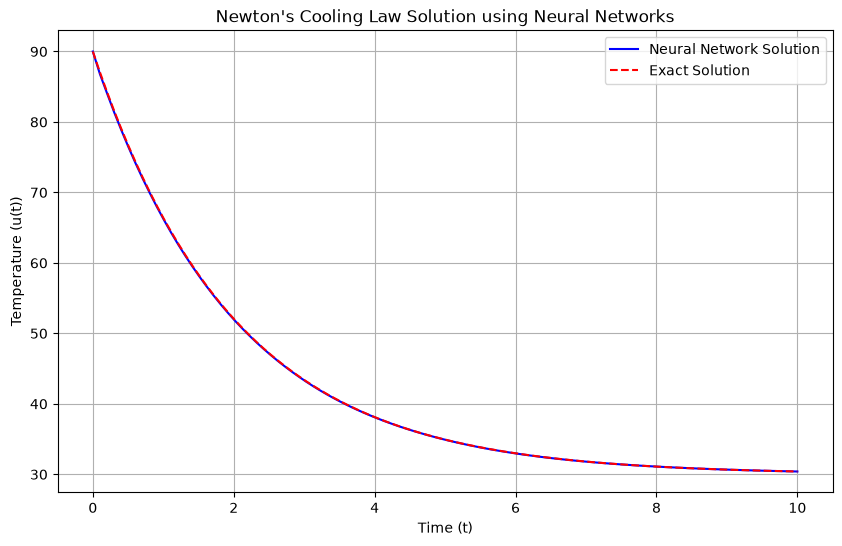

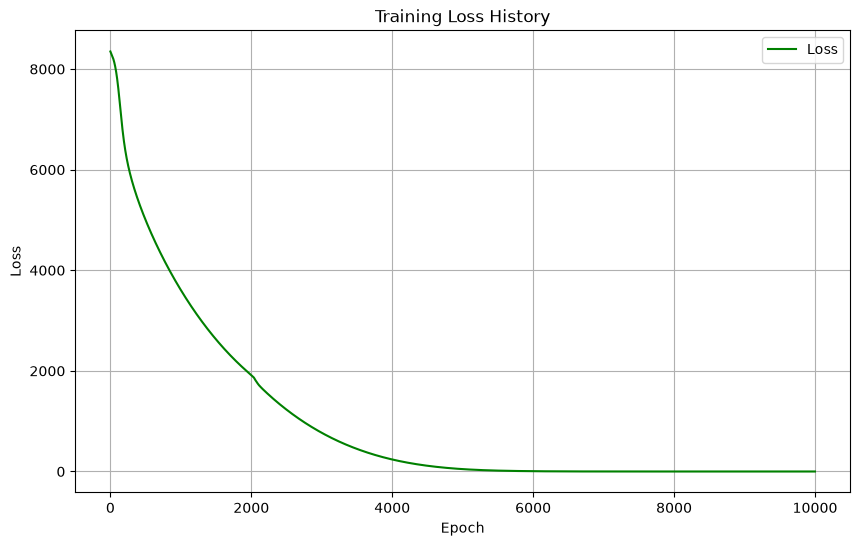

In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Constants for the problem
T = 30       # Ambient temperature
u0 = 90     # Initial temperature
k = 0.5      # Decay constant

# Time domain (converted to TensorFlow tensor)
t = np.linspace(0, 10, 100).reshape(-1, 1)
t = tf.convert_to_tensor(t, dtype=tf.float32)  # Convert t to TensorFlow tensor

# Build the neural network model
model = Sequential([
    Dense(20, activation='tanh', input_shape=(1,)),
    Dense(20, activation='tanh'),
    Dense(1, activation='linear')
])

# Loss function for Newton's Law of Cooling
def cooling_loss(t, u_pred):
    with tf.GradientTape() as tape:
        tape.watch(t)
        u = model(t)  # Compute the network prediction for u(t)
    u_t = tape.gradient(u, t)  # Derivative of u(t) with respect to t

    # Newton's cooling equation: u_t + k(u - T) = 0
    pde_loss = tf.reduce_mean(tf.square(u_t + k * (u - T)))

    # Boundary condition loss: u(0) = u0
    boundary_loss = tf.square(model(tf.convert_to_tensor([[0.0]], dtype=tf.float32)) - u0)

    # Total loss
    return pde_loss + boundary_loss

# Custom training loop
optimizer = tf.keras.optimizers.Adam()

# Training loop
epochs = 10000
loss_history = []
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        u_pred = model(t)  # Get predictions for u(t)
        loss = cooling_loss(t, u_pred)  # Calculate the loss

    # Compute the gradients and apply optimization
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    # Record the loss value
    loss_history.append(loss.numpy())

    # Print progress every 500 epochs
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy()}")

# Predict u(t) for plotting
t_test = np.linspace(0, 10, 100).reshape(-1, 1)
t_test = tf.convert_to_tensor(t_test, dtype=tf.float32)  # Convert t_test to TensorFlow tensor
u_pred = model.predict(t_test)

# Exact solution
u_exact = T + (u0 - T) * np.exp(-k * t_test)

# Plot the neural network solution and the exact solution
plt.figure(figsize=(10, 6))
plt.plot(t_test.numpy(), u_pred, label="Neural Network Solution", color='b')
plt.plot(t_test.numpy(), u_exact, label="Exact Solution", linestyle='dashed', color='r')
plt.xlabel('Time (t)')
plt.ylabel('Temperature (u(t))')
plt.title("Newton's Cooling Law Solution using Neural Networks")
plt.legend()
plt.grid(True)
plt.show()

# Plot the loss history
# Convert the loss history to a 1D array
loss_history = [loss.item() for loss in loss_history]

# Plot the loss history
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), loss_history, label="Loss", color='g')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.legend()
plt.grid(True)
plt.show()


This is a perfect match. This "unsupervised" learning provides the exact solution. But it takes far too long to learn the solution...
Can we do it faster? Maybe using some data points obtained from measurements
of the coffee temperature?

Note that we changed the activation function to ReLu to avoid vanishing gradients.



**Supervised Learning: Neural Network Interpolation of Data**

The next code builds a neural network to learn the temperature from 10 given measurements. It has two hidden layers, 40 neurons each, and it is trained for 2000 epochs. The results are not a perfect match. Why? Because information is missing between the measurements!

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step


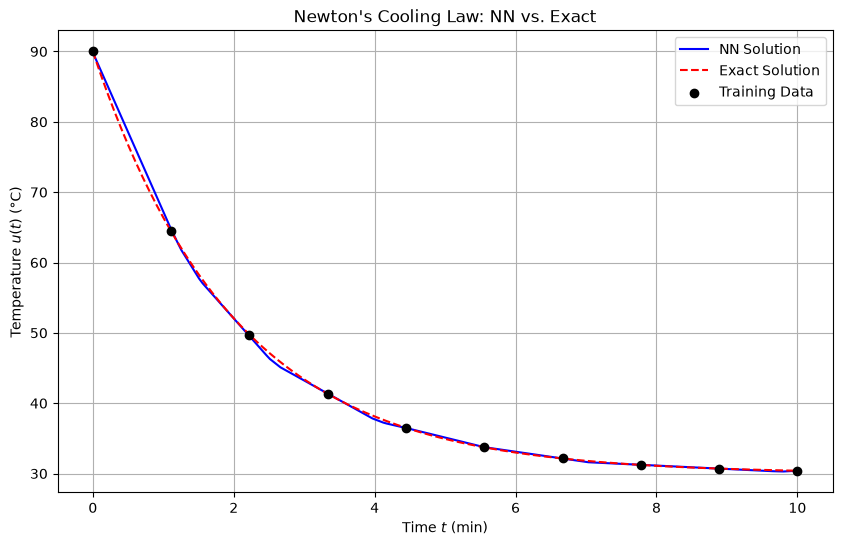

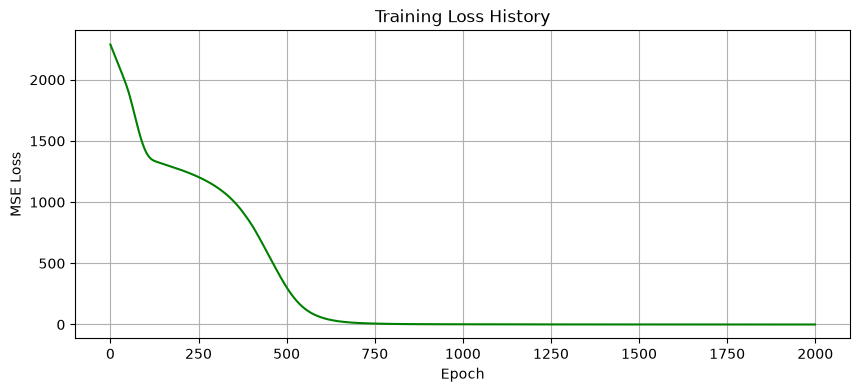

In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt

# --- 1) Problem setup --------------------------------------------------------

# Newton’s law constants
T_env = 30.0        # ambient temperature
u0    = 90.0        # initial temperature
k     = 0.5         # decay constant

# Exact solution for comparison
def exact_solution(t):
    return T_env + (u0 - T_env) * np.exp(-k * t)

# Data points (t, u) to enforce
t_data = np.linspace(0, 10, 10).reshape(-1, 1).astype(np.float32)
u_data = exact_solution(t_data)

# --- 2) Build the network ---------------------------------------------------

model = Sequential([
    Input(shape=(1,)),
    Dense(40, activation='relu'),
    Dense(40, activation='relu'),
    Dense(1,  activation='linear')
])

# --- 3) Compile with loss = MSE on the known points ------

model.compile(
    optimizer='adam',
    loss='mse'
)

# --- 4) Train only on the data points ---------------------------------------

history = model.fit(
    t_data, u_data,
    epochs=2000,
    batch_size=10,
    verbose=0
)

# --- 5) Evaluate & plot -----------------------------------------------------

# A fine grid for plotting
t_plot = np.linspace(0, 10, 200).reshape(-1, 1).astype(np.float32)

u_pred  = model.predict(t_plot)
u_exact = exact_solution(t_plot)

plt.figure(figsize=(10,6))
plt.plot(t_plot, u_pred,  label="NN Solution", color='b')
plt.plot(t_plot, u_exact, label="Exact Solution", linestyle='--', color='r')
plt.scatter(t_data, u_data, color='k', label="Training Data", zorder=5)
plt.xlabel('Time $t$ (min)')
plt.ylabel('Temperature $u(t)$ (°C)')
plt.title("Newton's Cooling Law: NN vs. Exact")
plt.legend()
plt.grid(True)
plt.show()

# Plot training loss
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], color='g')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss History')
plt.grid(True)
plt.show()


**Comparison of Loss function evolution**

The next code provides the loss function for three architectures: Arch #1: one layer with 20 neurons, Arch#2 with 2 layers, 40-20 neurons, and Arch#3 with three layers 80-40-20 neurons.


Training architecture #1 ...



Training architecture #2 ...

Training architecture #3 ...


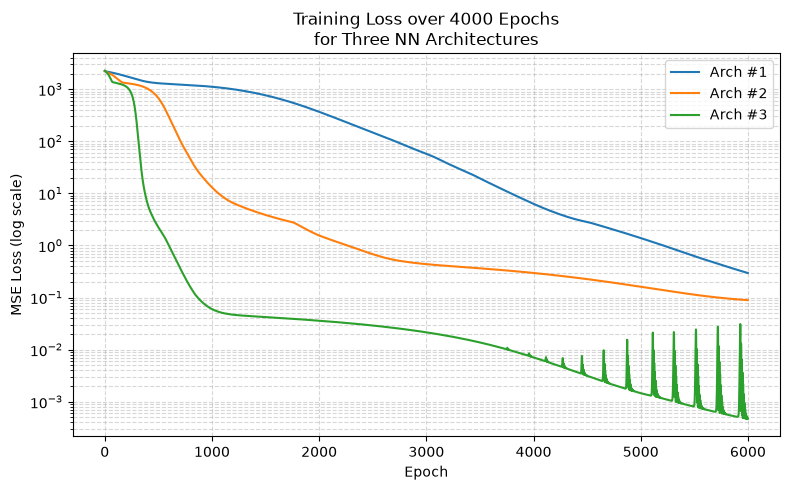

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# --- 1) Prepare the data ----------------------------------------------------
T_env = 30.0
u0    = 90.0
k     = 0.5

def exact_solution(t):
    return T_env + (u0 - T_env) * np.exp(-k * t)

# Ten sample points
t_data = np.linspace(0, 10, 10).reshape(-1,1).astype(np.float32)
u_data = exact_solution(t_data)

# --- 2) Define three architectures -----------------------------------------

def make_model(arch_id):
    m = Sequential([ Input(shape=(1,)) ])
    if arch_id == 1:
        m.add(Dense(20, activation='relu'))
    elif arch_id == 2:
        m.add(Dense(40, activation='relu'))
        m.add(Dense(20, activation='relu'))
    else:  # arch_id == 3
        m.add(Dense(80, activation='relu'))
        m.add(Dense(40, activation='relu'))
        m.add(Dense(20, activation='relu'))
    m.add(Dense(1, activation='linear'))
    m.compile(optimizer='adam', loss='mse')
    return m

# --- 3) Train all three, record loss histories ------------------------------

histories = {}
epochs = 6000

for arch in [1,2,3]:
    model = make_model(arch)
    print(f"\nTraining architecture #{arch} ...")
    h = model.fit(
        t_data, u_data,
        epochs=epochs,
        batch_size=10,
        verbose=0
    )
    histories[arch] = h.history['loss']

# --- 4) Plot all three loss curves ------------------------------------------

plt.figure(figsize=(8,5))
for arch, loss_hist in histories.items():
    plt.plot(loss_hist, label=f"Arch #{arch}")
plt.yscale('log')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (log scale)")
plt.title("Training Loss over 4000 Epochs\nfor Three NN Architectures")
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Hybrid Approach**

Next we consider a hybrid approach. This means that besides data measurements we also use the PINN approach, which fills the info in between measurements.

Epoch 0, Loss: [[9914.499]]
Epoch 500, Loss: [[6.006865]]
Epoch 1000, Loss: [[2.0218687]]
Epoch 1500, Loss: [[1.9033567]]
Epoch 2000, Loss: [[1.8698204]]
Epoch 2500, Loss: [[1.8562561]]
Epoch 3000, Loss: [[1.8478614]]
Epoch 3500, Loss: [[1.7941464]]
Epoch 4000, Loss: [[1.7931056]]
Epoch 4500, Loss: [[1.7931005]]
Epoch 5000, Loss: [[1.7935799]]
Epoch 5500, Loss: [[1.7870195]]
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step


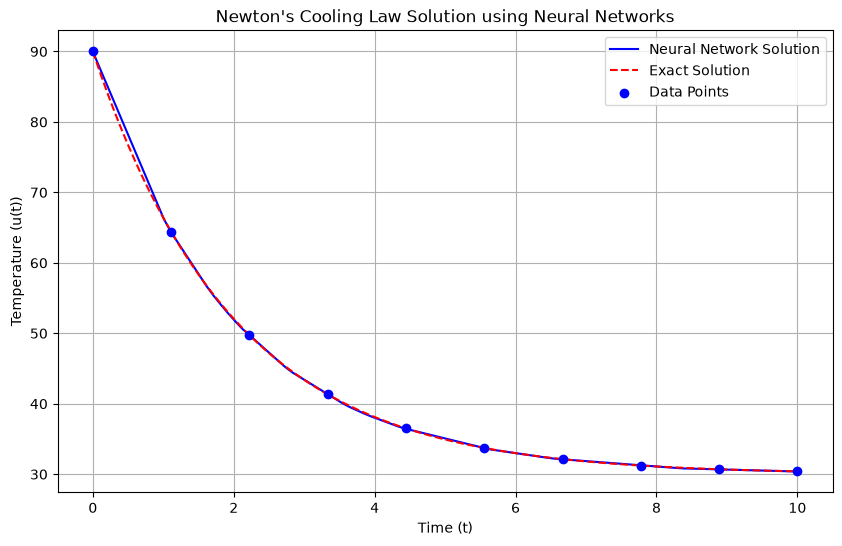

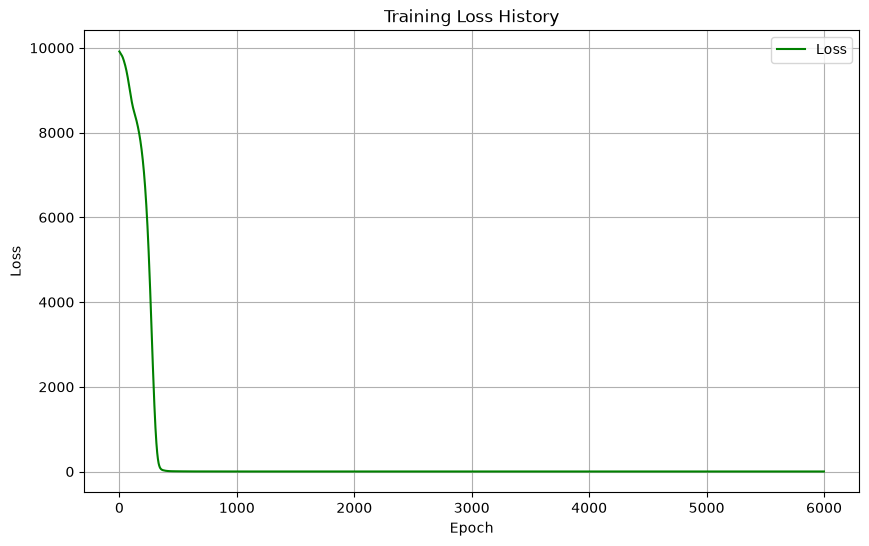

In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Constants for the problem
T = 30       # Ambient temperature
u0 = 90     # Initial temperature
k = 0.5      # Decay constant

# Exact solution of Newton's Law of Cooling
def exact_solution(t):
    return T + (u0 - T) * np.exp(-k * t)

# Time domain (converted to TensorFlow tensor)
t = np.linspace(0, 10, 100).reshape(-1, 1)
t = tf.convert_to_tensor(t, dtype=tf.float32)  # Convert t to TensorFlow tensor



# Build the neural network model
model = Sequential([
    Dense(40, activation='relu', input_shape=(1,)),
    Dense(30, activation='relu'),
    Dense(20, activation='relu'),
    Dense(1, activation='linear')
])

# Loss function for Newton's Law of Cooling
def cooling_loss(t, u_pred):
    with tf.GradientTape() as tape:
        tape.watch(t)
        u = model(t)  # Compute the network prediction for u(t)
    u_t = tape.gradient(u, t)  # Derivative of u(t) with respect to t

    # Newton's cooling equation: u_t + k(u - T) = 0
    pde_loss = tf.reduce_mean(tf.square(u_t + k * (u - T)))

    # Boundary condition loss: u(0) = u0
    boundary_loss1 = tf.square(model(tf.convert_to_tensor([[0.0]], dtype=tf.float32)) - u0)

    # Total loss
    #return pde_loss + boundary_loss

      # Boundary condition loss: u(0) = u0 and additional boundary points
    boundary_times = tf.convert_to_tensor([[0.0], [1.11], [2.22], [3.33], [4.44], [5.56], [6.67], [7.78], [8.89], [10.00]], dtype=tf.float32)
    boundary_values = u0 * np.exp(-k * boundary_times) + T * (1 - np.exp(-k * boundary_times))
    boundary_loss = tf.reduce_mean(tf.square(model(boundary_times) - boundary_values))

    # Total loss
    return pde_loss + 1*boundary_loss1+ 0.7*boundary_loss

# Custom training loop
optimizer = tf.keras.optimizers.Adam()

# Training loop
epochs = 6000
loss_history = []
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        u_pred = model(t)  # Get predictions for u(t)
        loss = cooling_loss(t, u_pred)  # Calculate the loss

    # Compute the gradients and apply optimization
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    # Record the loss value
    loss_history.append(loss.numpy())

    # Print progress every 500 epochs
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy()}")

# Predict u(t) for plotting
t_test = np.linspace(0, 10, 100).reshape(-1, 1)
t_test = tf.convert_to_tensor(t_test, dtype=tf.float32)  # Convert t_test to TensorFlow tensor
u_pred = model.predict(t_test)

# Exact solution
u_exact = T + (u0 - T) * np.exp(-k * t_test)


# Data points
t_data = np.linspace(0, 10, 10).reshape(-1, 1)
u_data = exact_solution(t_data)


# Plot the neural network solution and the exact solution
plt.figure(figsize=(10, 6))
plt.plot(t_test.numpy(), u_pred, label="Neural Network Solution", color='b')
plt.plot(t_test.numpy(), u_exact, label="Exact Solution", linestyle='dashed', color='r')
plt.scatter(t_data, u_data, color='b', label="Data Points", zorder=5)
plt.xlabel('Time (t)')
plt.ylabel('Temperature (u(t))')
plt.title("Newton's Cooling Law Solution using Neural Networks")
plt.legend()
plt.grid(True)
plt.show()

# Plot the loss history
# Convert the loss history to a 1D array
loss_history = [loss.item() for loss in loss_history]

# Plot the loss history
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), loss_history, label="Loss", color='g')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.legend()
plt.grid(True)
plt.show()


**An improved variant of learning**

We modify the code by looking for a solution of the form:
$$
u(t)=u(0)+t⋅NN(θ,t).
$$
We introduce this form explicitly into the model. The neural network

$NN(θ,t)$ represents the correction term, and the boundary condition
$
u(0)=u_0$
is automatically satisfied. Here's the modified code:

Epoch 0, Loss: 735.9942016601562
Epoch 500, Loss: 117.66107177734375
Epoch 1000, Loss: 33.257808685302734
Epoch 1500, Loss: 15.547928810119629
Epoch 2000, Loss: 7.991781234741211
Epoch 2500, Loss: 4.487733364105225
Epoch 3000, Loss: 2.6412699222564697
Epoch 3500, Loss: 1.586873173713684
Epoch 4000, Loss: 0.9629649519920349
Epoch 4500, Loss: 0.5930348038673401


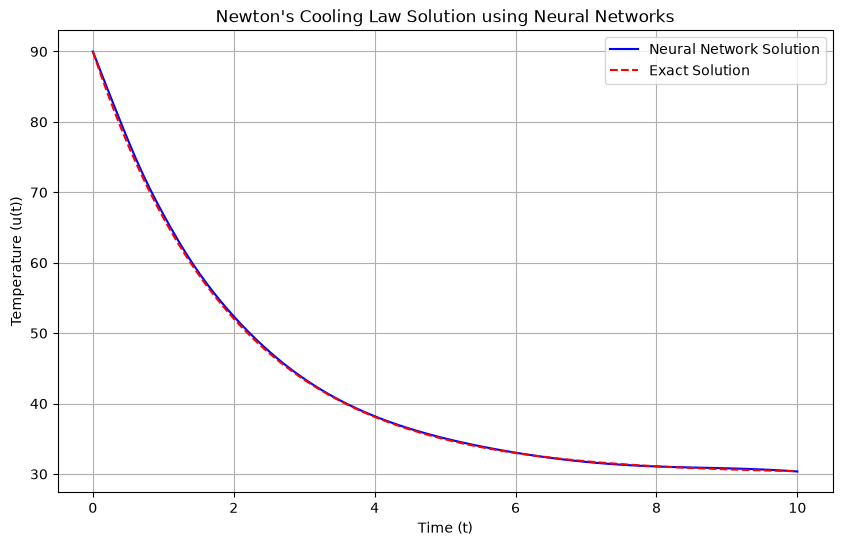

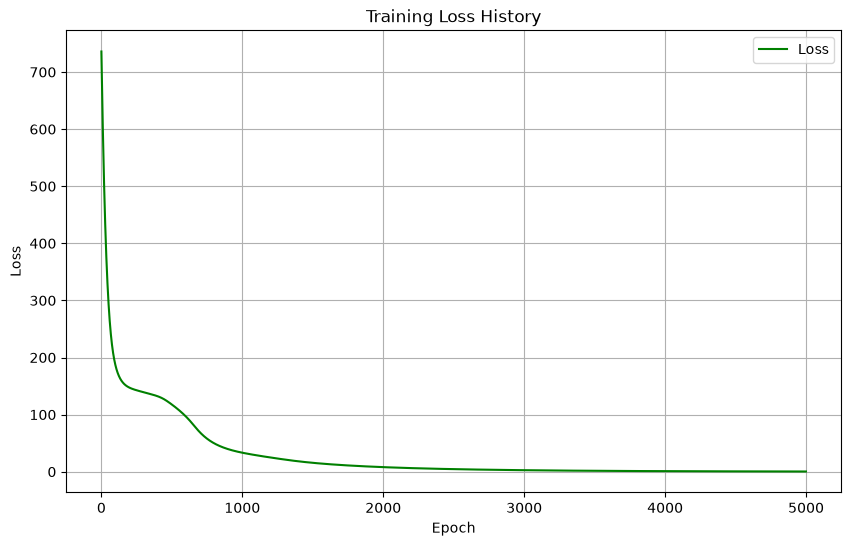

In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Constants for the problem
T = 30       # Surrounding temperature
u0 = 90      # Initial temperature
k = 0.5      # Cooling constant

# Time domain (converted to TensorFlow tensor)
t = np.linspace(0, 10, 100).reshape(-1, 1)
t = tf.convert_to_tensor(t, dtype=tf.float32)  # Convert t to TensorFlow tensor

# Build the neural network model
model = Sequential([
    Dense(20, activation='tanh', input_shape=(1,)),
    Dense(20, activation='tanh'),
    Dense(1, activation='linear')
])

# Define the custom solution form: u(t) = u0 + t * NN(t)
def solution(t):
    nn_output = model(t)
    return u0 + t * nn_output

# Loss function for Newton's Law of Cooling
def cooling_loss(t):
    with tf.GradientTape() as tape:
        tape.watch(t)
        u = solution(t)  # Compute the solution u(t) using the custom form
    u_t = tape.gradient(u, t)  # Derivative of u(t) with respect to t

    # Newton's cooling equation: u_t + k(u - T) = 0
    pde_loss = tf.reduce_mean(tf.square(u_t + k * (u - T)))

    # Total loss
    return pde_loss

# Custom training loop
optimizer = tf.keras.optimizers.Adam()

# Training loop
epochs = 5000
loss_history = []
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        loss = cooling_loss(t)  # Calculate the loss

    # Compute the gradients and apply optimization
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    # Record the loss value
    loss_history.append(loss.numpy())

    # Print progress every 500 epochs
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy()}")

# Predict u(t) for plotting
t_test = np.linspace(0, 10, 100).reshape(-1, 1)
t_test = tf.convert_to_tensor(t_test, dtype=tf.float32)  # Convert t_test to TensorFlow tensor
u_pred = solution(t_test).numpy()  # Compute u(t) using the trained neural network

# Exact solution
u_exact = T + (u0 - T) * np.exp(-k * t_test)

# Plot the neural network solution and the exact solution
plt.figure(figsize=(10, 6))
plt.plot(t_test.numpy(), u_pred, label="Neural Network Solution", color='b')
plt.plot(t_test.numpy(), u_exact, label="Exact Solution", linestyle='dashed', color='r')
plt.xlabel('Time (t)')
plt.ylabel('Temperature (u(t))')
plt.title("Newton's Cooling Law Solution using Neural Networks")
plt.legend()
plt.grid(True)
plt.show()

# Plot the loss history
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), loss_history, label="Loss", color='g')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.legend()
plt.grid(True)
plt.show()


**Hybrid approach**

Epoch 0, Loss: 5102.0283203125
Epoch 500, Loss: 116.98007202148438
Epoch 1000, Loss: 6.529690742492676
Epoch 1500, Loss: 3.079873561859131
Epoch 2000, Loss: 1.9438576698303223
Epoch 2500, Loss: 1.0634949207305908
Epoch 3000, Loss: 0.6827779412269592
Epoch 3500, Loss: 0.37868520617485046
Epoch 4000, Loss: 0.23845763504505157
Epoch 4500, Loss: 0.2137146145105362


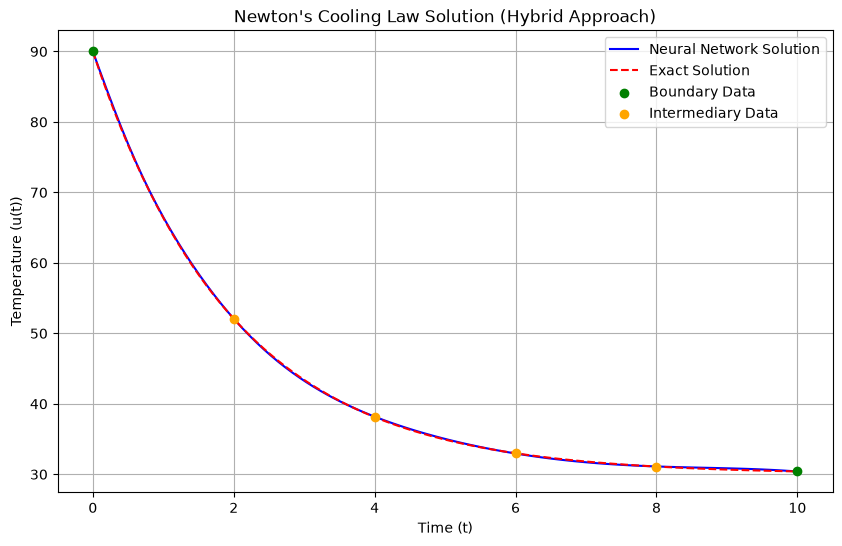

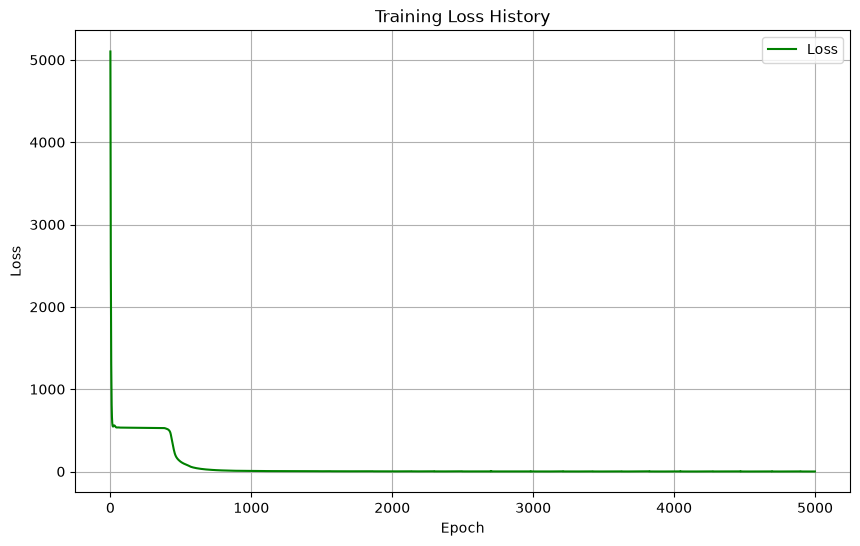

In [13]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

# Constants for the problem
T = 30       # Surrounding temperature
u0 = 90      # Initial temperature
k = 0.5      # Cooling constant

# Time domain for training
t = np.linspace(0, 10, 100).reshape(-1, 1)  # 100 time points for training

# Boundary data points
t_boundary = np.array([[0.0], [10.0]])  # Initial and final time
u_boundary = np.array([[u0], [T + (u0 - T) * np.exp(-k * 10)]])

# Intermediary data points (4 points)
t_intermediary = np.array([[2.0], [4.0], [6.0], [8.0]])
u_intermediary = T + (u0 - T) * np.exp(-k * t_intermediary)  # Analytical solution for intermediary points

# Convert to TensorFlow tensors
t_boundary = tf.convert_to_tensor(t_boundary, dtype=tf.float32)
u_boundary = tf.convert_to_tensor(u_boundary, dtype=tf.float32)
t_intermediary = tf.convert_to_tensor(t_intermediary, dtype=tf.float32)
u_intermediary = tf.convert_to_tensor(u_intermediary, dtype=tf.float32)
t = tf.convert_to_tensor(t, dtype=tf.float32)

# Build the neural network model
model = Sequential([
    Dense(20, activation='tanh', input_shape=(1,)),
    Dense(20, activation='tanh'),
    Dense(1, activation='linear')
])

# Define the custom solution form: u(t) = u0 + t * NN(t)
def solution(t):
    nn_output = model(t)
    return u0 + t * nn_output

# Loss function
def hybrid_loss(t, t_boundary, u_boundary, t_intermediary, u_intermediary):
    # Physics-Informed Loss (PDE)
    with tf.GradientTape() as tape:
        tape.watch(t)
        u = solution(t)  # Compute the solution u(t)
    u_t = tape.gradient(u, t)  # Derivative of u(t) with respect to t
    pde_loss = tf.reduce_mean(tf.square(u_t + k * (u - T)))

    # Boundary Loss (Supervised at t_boundary)
    u_pred_boundary = solution(t_boundary)
    boundary_loss = tf.reduce_mean(tf.square(u_pred_boundary - u_boundary))

    # Intermediary Loss (Supervised at intermediary points)
    u_pred_intermediary = solution(t_intermediary)
    intermediary_loss = tf.reduce_mean(tf.square(u_pred_intermediary - u_intermediary))

    # Total Loss
    return pde_loss + boundary_loss + intermediary_loss

# Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

# Training loop
epochs = 5000
loss_history = []
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        loss = hybrid_loss(t, t_boundary, u_boundary, t_intermediary, u_intermediary)  # Calculate the loss

    # Compute the gradients and apply optimization
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    # Record the loss value
    loss_history.append(loss.numpy())

    # Print progress every 500 epochs
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss.numpy()}")

# Predict u(t) for plotting
t_test = np.linspace(0, 10, 100).reshape(-1, 1)
t_test = tf.convert_to_tensor(t_test, dtype=tf.float32)  # Convert t_test to TensorFlow tensor
u_pred = solution(t_test).numpy()  # Compute u(t) using the trained neural network

# Exact solution
u_exact = T + (u0 - T) * np.exp(-k * t_test)

# Plot the neural network solution and the exact solution
plt.figure(figsize=(10, 6))
plt.plot(t_test.numpy(), u_pred, label="Neural Network Solution", color='b')
plt.plot(t_test.numpy(), u_exact, label="Exact Solution", linestyle='dashed', color='r')
plt.scatter(t_boundary.numpy(), u_boundary.numpy(), color='g', label="Boundary Data", zorder=5)
plt.scatter(t_intermediary.numpy(), u_intermediary.numpy(), color='orange', label="Intermediary Data", zorder=5)
plt.xlabel('Time (t)')
plt.ylabel('Temperature (u(t))')
plt.title("Newton's Cooling Law Solution (Hybrid Approach)")
plt.legend()
plt.grid(True)
plt.show()

# Plot the loss history
plt.figure(figsize=(10, 6))
plt.plot(range(epochs), loss_history, label="Loss", color='g')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss History')
plt.legend()
plt.grid(True)
plt.show()
